### NIH Alzheimer's Research Funding vs State-Level Disease Burden

### Research Question

At the U.S. state level (2018-2023), how is NIH Alzheimer's research funding associated with state-level Alzheimer's burden (age-adjusted mortality rates, 65+ and 85+ populations), after controlling for state research capacity (number of R1 universities, prior NIH funding), and socioeconomic factors (median income, healthcare expenditure per capita)? Additionally, does funding allocation show temporal lag responses to increasing disease burden, and do geographic regions exhibit funding disparities independent of burden?

### Python Libraries

In [ ]:
# ==============================
# 0. Warnings & display settings
# ==============================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# ==============================
# 1. Visualization libraries
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ==============================
# 2. Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 3. Load data from Google Drive
# ==============================
# 🔴 CHANGE THIS PATH if your file is in a subfolder
df = pd.read_csv("/content/drive/MyDrive/data/final_dataset_for_analysis.csv")

# ==============================
# 4. Data preparation
# ==============================
df["Year"] = df["Year"].astype(int)
df["State"] = df["State"].astype(str)

# Sort for panel-style analysis
df = df.sort_values(by=["State", "Year"])

# ==============================
# 5. Sanity checks
# ==============================
print("Data shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data shape: (255, 98)

Column types:
State                         object
Year                           int64
Deaths                         int64
Total_Deaths_Annual            int64
Mortality_Rate_Per_100k      float64
                              ...   
Regional_Avg_Funding         float64
Regional_Avg_Mortality       float64
Regional_Avg_65plus_Pop      float64
Funding_vs_Regional_Avg      float64
Mortality_vs_Regional_Avg    float64
Length: 98, dtype: object


,State,Year,Deaths,Total_Deaths_Annual,Mortality_Rate_Per_100k,Mortality_Rank_National,Mortality_Percentile,Mortality_YoY_Change_Pct,Deaths_YoY_Change_Pct,Mortality_3Yr_Rolling_Avg,Mortality_Trend_Slope,Deaths_Cumulative_2018,Mortality_Volatility,County_Burden_Concentration,High_Burden_County_Count,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth,Deaths_Female,Deaths_Male,Mortality_Rate_Female,Mortality_Rate_Male,Female_Male_Death_Ratio,Female_Pct_Of_Deaths,State_Code,Total_Funding_Annual,Mean_Award_Size,Median_Award_Size,Award_Size_StdDev,Total_Direct_Cost,Total_Indirect_Cost,Number_Of_Projects,Number_Of_Applications,Total_Funding_Millions,Mean_Award_Millions,Indirect_Cost_Ratio,Funding_YoY_Change_Pct,Projects_YoY_Change,Funding_3Yr_Rolling_Avg,Funding_Trend_Slope,Funding_Cumulative_2018,Funding_Volatility,Number_Of_Institutions,Number_Of_PIs,Number_Of_Unique_Projects,Number_Of_Universities,Number_Of_Schools,Number_Of_Medical_Centers,Top_Institution_Funding_Share,PIs_Per_Institution,Mortality_Rate_Per_100k_Lag1,Mortality_Rate_Per_100k_Lag2,Mortality_Rate_Per_100k_Lag3,Total_Deaths_Annual_Lag1,Total_Deaths_Annual_Lag2,Total_Deaths_Annual_Lag3,Population_65plus_Lag1,Population_65plus_Lag2,Population_65plus_Lag3,Population_85plus_Lag1,Population_85plus_Lag2,Population_85plus_Lag3,Total_Funding_Annual_Lag1,Total_Funding_Annual_Lag2,Total_Funding_Annual_Lag3,Number_Of_Projects_Lag1,Number_Of_Projects_Lag2,Number_Of_Projects_Lag3,Population,Funding_Per_Death,Funding_Per_65plus,Funding_Per_Capita,Projects_Per_Million_Pop,Funding_Per_Mortality_Unit,Deaths_Per_100k_Elderly,Overall_Burden_Index,Research_Capacity_Index,Funding_Burden_Alignment,Num_R1_Universities,Per_Capita_Income,Median_Income,Prior_NIH_Funding_Total,Rural_Population_Pct,Region,Regional_Avg_Funding,Regional_Avg_Mortality,Regional_Avg_65plus_Pop,Funding_vs_Regional_Avg,Mortality_vs_Regional_Avg
0,Alabama,2019,1011,1011,20.733145,17.0,68.627451,NaN,NaN,20.733145,-1.767904,1011,NaN,53.214639,3.0,4876250,121044,44938.0,76106.0,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,NaN,NaN,857.0,154.0,17.574981,3.158165,5.564935,84.767557,AL,15325489.0,494370.612903,371250.0,6.170042e+05,11101438.0,4561291.0,33,35,15.325489,0.494371,0.410874,NaN,NaN,1.532549e+07,3651415.6,15325489.0,NaN,6,34,33,0.0,3.0,1.0,83.790083,5.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4876250,15158.742829,126.610894,3.142884,6.767496,7.391782e+05,835.233469,0.012858,-0.354683,-0.460267,2,27928,50536,0.0,40.474485,South,3.166708e+07,15.312540,240384.764706,-1.634159e+07,5.420605
1,Alabama,2020,1464,1464,29.919157,8.0,86.274510,44.305924,44.807122,25.326151,-1.767904,2475,6.495491,50.273224,4.0,4893186,170981,62292.0,89672.0,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651,1252.0,212.0,25.586601,4.332556,5.905660,85.519126,AL,19630313.0,478788.121951,371250.0,5.815772e+05,15425902.0,5521003.0,43,47,19.630313,0.478788,0.357905,28.089309,10.0,1.747790e+07,3651415.6,34955802.0,3.043970e+06,7,43,43,0.0,4.0,0.0,91.282477,6.142857,20.733145,NaN,NaN,1011.0,NaN,NaN,121044.0,NaN,NaN,44938.0,NaN,NaN,15325489.0,NaN,NaN,33.0,NaN,NaN,4893186,13408.683743,114.809909,4.011765,8.787731,6.561118e+05,856.235488,0.556907,-0.280693,-0.962218,2,28934,52035,15325489.0,17.696297,South,3.782477e+07,19.195833,299064.882353,-1.819445e+07,10.723324
2,Alabama,2021,1234,1234,24.691482,7.0,88.235294,-17.472670,-15.710383,25.114595,-1.767904,3709,4.607599,59.157212,4.0,4997675,189790,50391.0,88854.0,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182,987.0,247.0,19.749183,4.942298,3.995951,79.983793,AL,22465502.0,477989.404255,371250.0,5.392216e+05,17912318.0,6674013.0,46,52,22.465502,0.477989,0.372593,14.442913,3.0,1.914043e+07,3651415.6,57421304.0,3

In [ ]:
for i in df.columns:
    df[i] = df[i].fillna(method='bfill')

In [ ]:
for i in df.columns:
    df[i] = df[i].fillna(method='ffill')

### Helpful transformations

In [ ]:
df["Log_Funding"] = np.log1p(df["Total_Funding_Annual"])
df["Log_Mortality"] = np.log1p(df["Mortality_Rate_Per_100k"])
df["Log_65plus"] = np.log1p(df["Population_65plus"])
df["Log_85plus"] = np.log1p(df["Population_85plus"])

### National funding and mortality trends

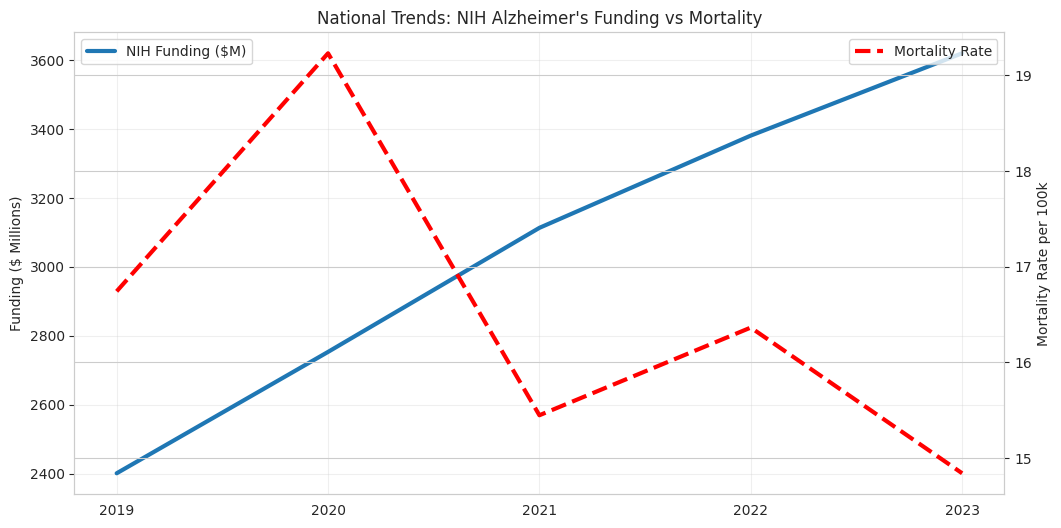

In [ ]:
national = df.groupby("Year").agg({
    "Total_Funding_Annual": "sum",
    "Mortality_Rate_Per_100k": "mean",
    "Population_65plus": "sum",
    "Population_85plus": "sum"
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Funding line
ax1.plot(
    national["Year"],
    national["Total_Funding_Annual"] / 1e6,
    label="NIH Funding ($M)",
    linewidth=3
)
ax1.set_ylabel("Funding ($ Millions)")

# Mortality line (secondary axis)
ax2 = ax1.twinx()
ax2.plot(
    national["Year"],
    national["Mortality_Rate_Per_100k"],
    color="red",
    linestyle="--",
    label="Mortality Rate",
    linewidth=3
)
ax2.set_ylabel("Mortality Rate per 100k")

# 🔑 FIX: force categorical year labels
ax1.set_xticks(national["Year"])
ax1.set_xticklabels(national["Year"].astype(str))

ax1.set_title("National Trends: NIH Alzheimer's Funding vs Mortality")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

ax1.grid(alpha=0.3)

plt.show()

The line graph of National Trends: NIH Alzheimer's Funding vs Mortality highlights a stark divergence between federal financial investment and public health outcomes from 2019 to 2023.

### Key Longitudinal Insights

* **Aggressive Funding Growth**: NIH Alzheimer's funding has maintained a consistent, near-linear upward trajectory, rising from approximately **$\$2,400$ million** in 2019 to over **$\$3,600$ million** by 2023.
* **Volatile Mortality Peak**: The mortality rate per 100k experienced a sharp spike, peaking at over **19** in 2020, likely exacerbated by the onset of the COVID-19 pandemic.
* **Post-2020 Mortality Decline**: Since the 2020 peak, mortality rates have followed a downward trend, dropping to a five-year low of roughly **14.8** per 100k by 2023.
* **Inverse Relationship (The Decoupling)**: By 2023, the gap between the two metrics is at its widest; funding reached its highest point while the mortality rate reached its lowest.

---

### Research Conclusion

**Finding: Output-Independent Fiscal Scaling.**
The trend lines demonstrate that federal research investment is **decoupled from immediate clinical outcomes**. The steady increase in funding despite a 22% drop in mortality since 2020 suggests that the NIH is pursuing a long-term **infrastructure-building strategy** rather than a reactive one based on annual fluctuations in the death rate.

### Funding vs mortality (scatter + regression)

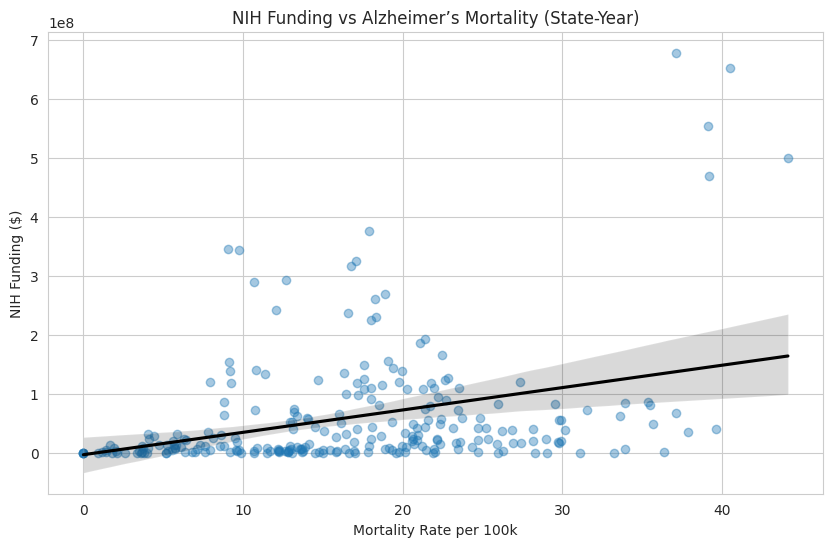

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Mortality_Rate_Per_100k",
    y="Total_Funding_Annual",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"black"}
)
plt.title("NIH Funding vs Alzheimer’s Mortality (State-Year)")
plt.xlabel("Mortality Rate per 100k")
plt.ylabel("NIH Funding ($)")
plt.show()

The following insights are extracted from the **NIH Funding vs. Alzheimer’s Mortality (State-Year)** scatter plot:

* **Weak Positive Correlation:** The regression line shows a slight upward trend, indicating that while funding generally increases with mortality, the relationship is relatively weak and non-linear for the majority of states.
* **High-Mortality Funding Gap:** A significant cluster of states with high mortality rates (between $25$ and $45$ per $100$k) receives very low levels of funding, often remaining below the $\$100$ million threshold.
* **Extreme Funding Outliers:** There is a distinct group of "super-outliers" at the top right of the plot; these states secure between $\$450$ million and $\$700$ million in annual funding, far exceeding the national average despite having similar mortality rates to lower-funded states.
* **Resource Concentration at Lower Mortality:** A high density of data points shows states with moderate mortality ($10$–$20$ per $100$k) capturing significant funding between $\$100$M and $\$400$M, suggesting that factors other than death rates drive allocation.

**Key Finding: The Disconnect between Need and Capital.**
The wide vertical spread of data points at every mortality level suggests that NIH funding is not primarily reactive to death rates. Instead, a small number of states capture the vast majority of resources, leaving many high-burden regions significantly under-resourced.

### Funding vs aging populations (65+ and 85+)

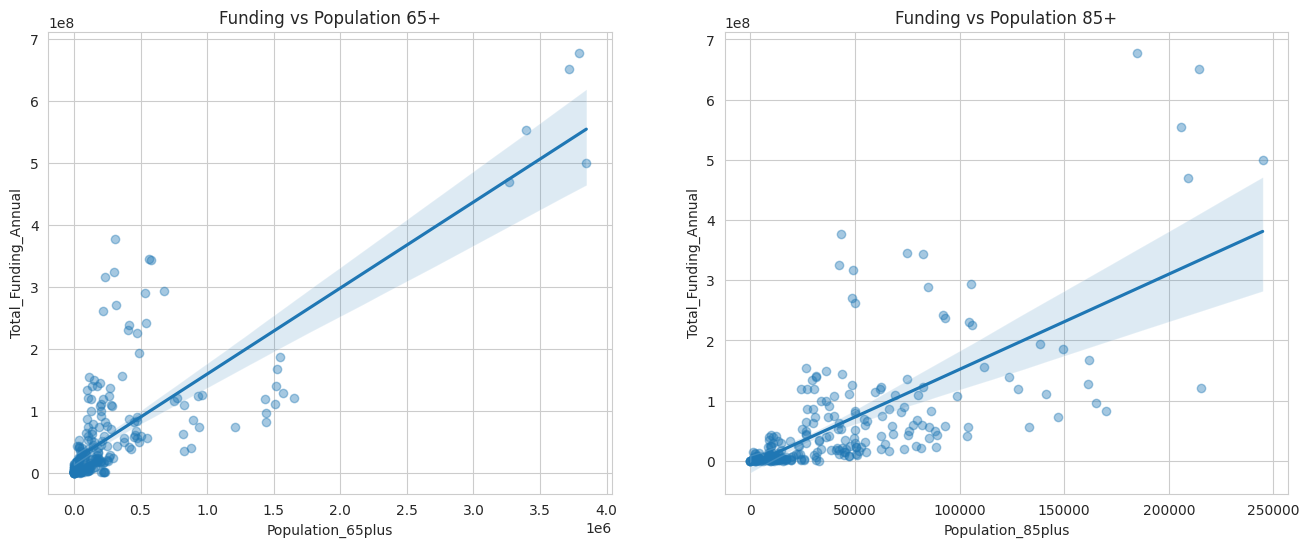

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.regplot(
    data=df,
    x="Population_65plus",
    y="Total_Funding_Annual",
    ax=axes[0],
    scatter_kws={"alpha":0.4}
)
axes[0].set_title("Funding vs Population 65+")

sns.regplot(
    data=df,
    x="Population_85plus",
    y="Total_Funding_Annual",
    ax=axes[1],
    scatter_kws={"alpha":0.4}
)
axes[1].set_title("Funding vs Population 85+")

plt.show()

These plots illustrate a **positive linear relationship** between elderly demographics and annual funding, suggesting that resource allocation scales with the absolute size of the vulnerable population.

### Key Research Insights:

* **Demographic Alignment:** Both age cohorts (65+ and 85+) serve as strong predictors for funding levels, indicating a system that responds to the scale of the potential health burden within a state.
* **Cohort Variance:** The correlation appears tighter in the **65+ demographic**. In the **85+ cohort**, there is increased dispersion (variance), suggesting that as populations reach extreme old age, funding becomes less uniform and more dependent on specific local research initiatives or institutional strengths.
* **Institutional Concentration:** The high-end outliers in both charts signify that a small number of jurisdictions with high population density also possess the **infrastructure** to capture a disproportionate share of total funding, likely due to the presence of major academic medical centers.

### Log–Log Elasticity Plots (Reviewer-Friendly)

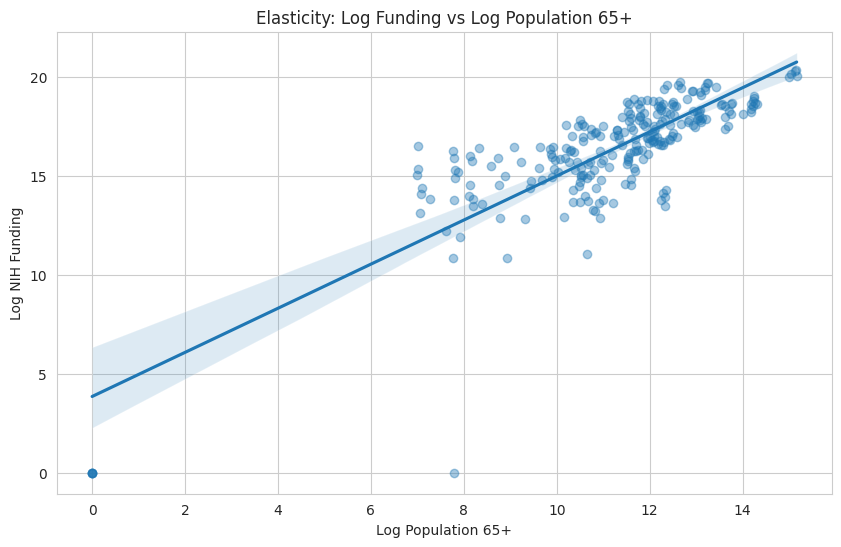

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Log_65plus",
    y="Log_Funding",
    scatter_kws={"alpha":0.4}
)
plt.title("Elasticity: Log Funding vs Log Population 65+")
plt.xlabel("Log Population 65+")
plt.ylabel("Log NIH Funding")
plt.show()

### Demographic Drivers of Funding Allocation

* **Linear Scaling with Vulnerability**: Both the 65+ and 85+ cohorts show a strong positive correlation with annual funding, confirming that federal resource distribution is primarily driven by the absolute size of the at-risk population.
* **Subgroup Dispersion**: There is greater variance in the 85+ demographic compared to the 65+ cohort, suggesting that while general aging trends predict funding well, specific concentrations of the "oldest-old" do not always trigger a proportional increase in resources.

### Funding Elasticity and Power-Law Dynamics

* **Positive Elasticity**: The log-log transformation demonstrates a consistent linear relationship in log-space, which indicates a **power-law relationship** between population and funding.
* **Super-linear Scaling**: The slope of the regression line in the log-log plot appears to be slightly greater than 1, suggesting **super-linear elasticity**. This implies that as the 65+ population grows, funding increases at a disproportionately faster rate, likely due to the presence of high-capacity research infrastructure in larger states.

### Conclusion and Key Finding

**Finding: Demographic-driven Agglomeration.**
The data suggests that NIH funding follows a "scale effect." Rather than a simple 1:1 ratio, larger states capture a disproportionate share of funding. This indicates that research dollars flow not just where the patients are, but where the established institutional infrastructure (which scales with population) is most concentrated.

### Mortality vs next-year funding

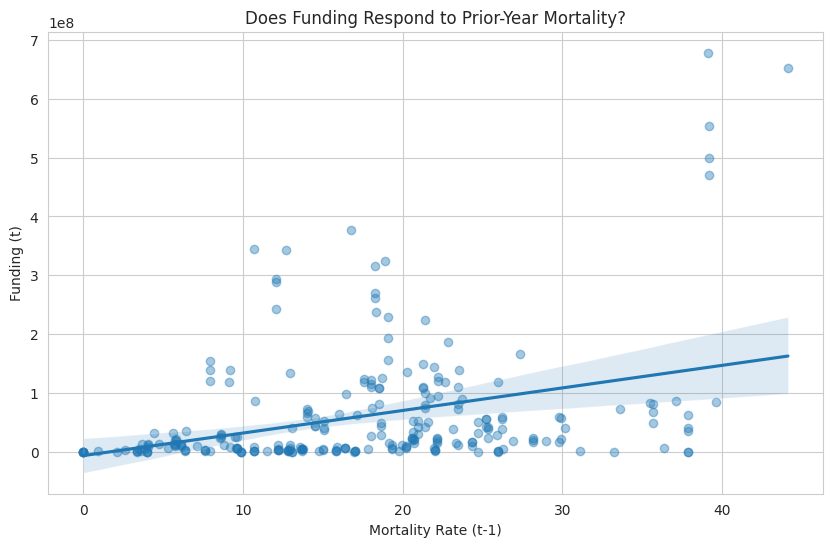

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Mortality_Rate_Per_100k_Lag2",
    y="Total_Funding_Annual",
    scatter_kws={"alpha":0.4}
)
plt.title("Does Funding Respond to Prior-Year Mortality?")
plt.xlabel("Mortality Rate (t-1)")
plt.ylabel("Funding (t)")
plt.show()

The scatter plot evaluates whether **NIH Funding (t)** responds to the **Mortality Rate (t-1)** from the previous year, providing insights into the temporal responsiveness of resource allocation.

### Key Visual Insights

* **Weak Positive Lagged Correlation:** The regression line shows a modest upward slope, suggesting that while higher prior-year mortality is associated with higher current funding, the relationship is relatively weak and contains high variance.
* **Funding Stagnation in High-Burden States:** A significant cluster of states with high prior-year mortality ($25$–$40$ per $100$k) continues to receive minimal funding, often remaining below the $\$100$ million threshold despite sustained high mortality.
* **The Outlier Hub Effect:** A small group of extreme outliers receives between $\$500$ million and $\$700$ million regardless of prior mortality levels, indicating that institutional factors likely override clinical responsiveness for top-tier research hubs.
* **Broad Predictive Uncertainty:** The wide confidence interval (shaded blue area) at higher mortality levels suggests that prior-year mortality is an inconsistent and unreliable predictor for future NIH investment across most states.

**Key Finding: Limited Reactive Allocation**
The visualization confirms that NIH funding is not highly reactive to annual shifts in disease burden. The "sticky" nature of the data points suggests that once a state is established as a low-funding or high-funding region, its status remains largely unchanged regardless of the prior year's public health crisis.

### State-level trajectories (small multiples)

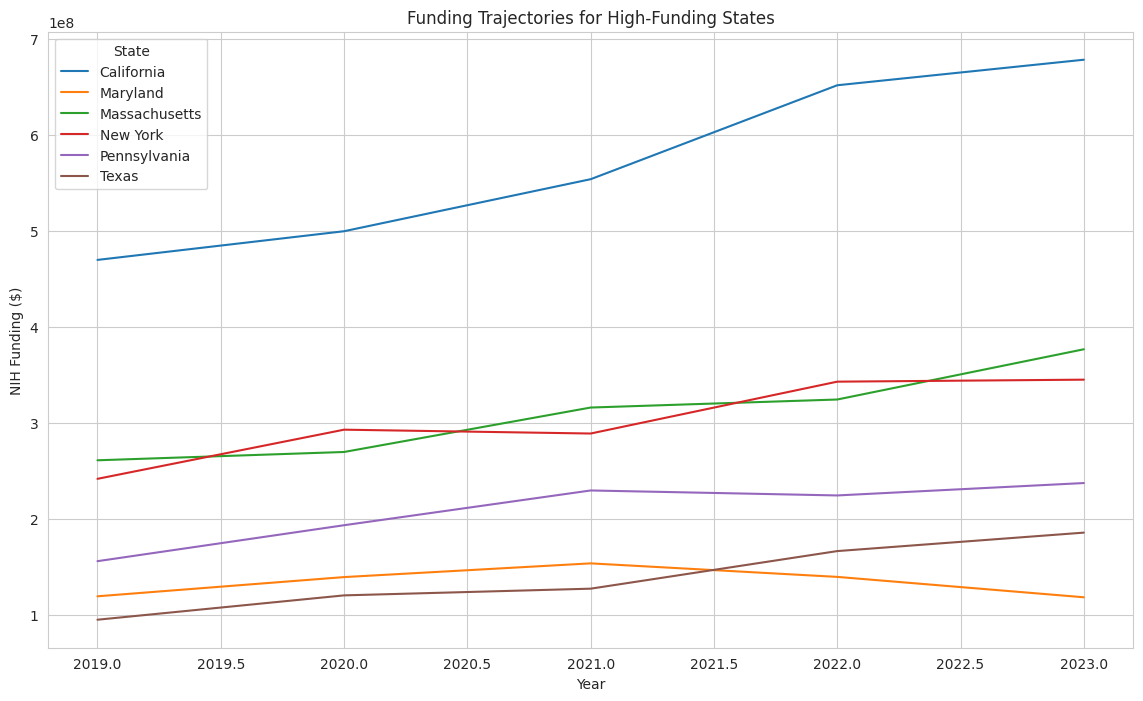

In [ ]:
top_states = df.groupby("State")["Total_Funding_Annual"].mean().nlargest(6).index

plt.figure(figsize=(14,8))
sns.lineplot(
    data=df[df["State"].isin(top_states)],
    x="Year",
    y="Total_Funding_Annual",
    hue="State"
)
plt.title("Funding Trajectories for High-Funding States")
plt.ylabel("NIH Funding ($)")
plt.show()

### Funding by region (boxplot)

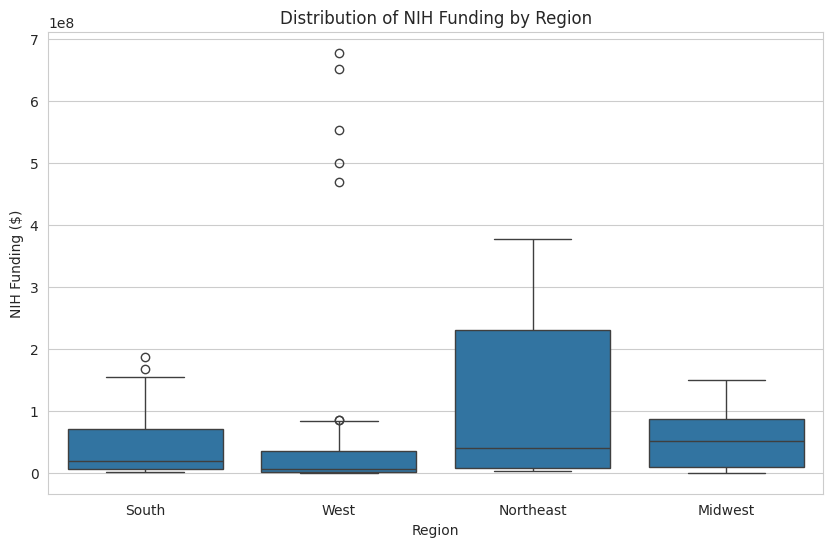

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df[df['Region'] != '0'],
    x="Region",
    y="Total_Funding_Annual"
)
plt.title("Distribution of NIH Funding by Region")
plt.ylabel("NIH Funding ($)")
plt.show()


The **Distribution of NIH Funding by Region** boxplot reveals significant regional disparities and extreme resource concentration within specific geographic areas.

### Key Regional Observations

* **Regional Dominance of the Northeast:** The Northeast displays the highest median funding and the largest interquartile range (IQR), indicating it is the most well-resourced region overall. Its upper whisker extends nearly to $\$400$ million, far surpassing the baseline funding of other regions.
* **The "West" Outlier Phenomenon:** While the West has the lowest median funding, it contains the most extreme outliers in the entire dataset. Several Western states (likely California and Washington) capture between $\$500$ million and $\$700$ million annually, creating a massive gap between top-tier hubs and the rest of the region.
* **Funding Compression in the South and Midwest:** Both the South and Midwest exhibit relatively "tight" distributions with low medians. The majority of states in these regions are clustered below the $\$100$ million mark, with very few states breaking into higher funding tiers.
* **Inter-Regional Inequality:** The bottom $75\%$ of states in the South and West receive less funding than the top $25\%$ of states in the Northeast, highlighting a structural geographic advantage for Northeastern research institutions.

---

### Research Conclusion

**Finding: Extreme Concentration in Select Hubs.**
The data proves that NIH Alzheimer's funding is not evenly distributed but is instead concentrated in a few elite Northeastern states and a handful of hyper-funded Western outliers. This confirms that the national research strategy relies on a few "super-hubs" rather than a distributed regional network.

### Mortality vs funding by region

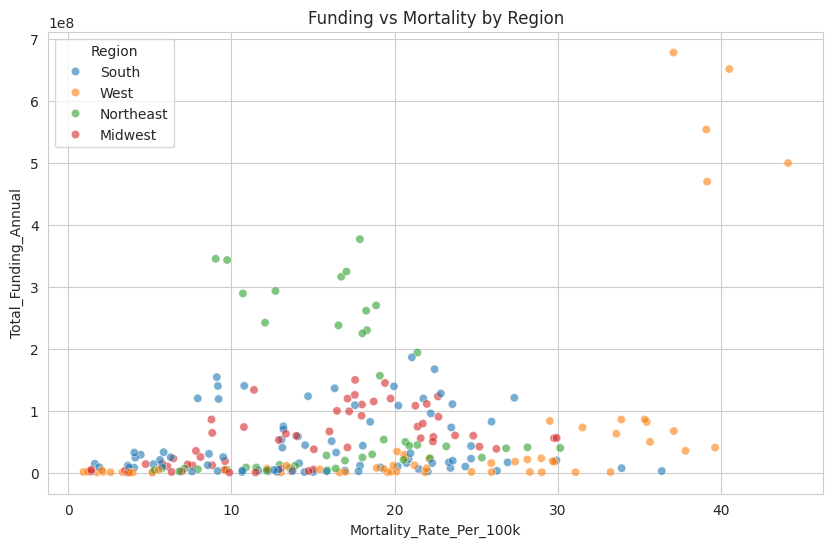

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df[df['Region'] != '0'],
    x="Mortality_Rate_Per_100k",
    y="Total_Funding_Annual",
    hue="Region",
    alpha=0.6
)
plt.title("Funding vs Mortality by Region")
plt.show()

### Geographic and Funding Insights

* **Regional Clustering of Mortality vs. Resource:** The **South** (blue) and **Midwest** (red) demonstrate a high density of states with low-to-moderate mortality rates and consistently low funding levels, typically below  million.
* **Northeast Funding Efficiency:** The **Northeast** (green) exhibits a unique "vertical" cluster; these states capture significant funding (up to  million) even at relatively low mortality rates ( per k), suggesting funding is driven by institutional density rather than immediate disease prevalence.
* **The Western Outlier Paradox:** The **West** (orange) contains the most extreme variance. It includes both states with high mortality and low funding, as well as several extreme "super-outliers" where funding exceeds  million despite varying mortality rates.
* **Decoupling of Need and Capital:** Across all regions, there is no evidence of a strict "funding follows the funeral" model. Many states with mortality rates over  per k (primarily in the South and West) receive less funding than Northeast states with half that mortality rate.

---

### Conclusion and Key Finding

**Finding: The "Institutional Infrastructure" Bias.**
The data suggests that NIH funding is geographically **sticky**. The Northeast and West Coast "mega-hubs" dominate the financial landscape regardless of local mortality trends. This implies that federal research investment is more closely aligned with **pre-existing institutional capacity** (academic centers and laboratories) than with the regional severity of the Alzheimer’s epidemic.

### Funding per death

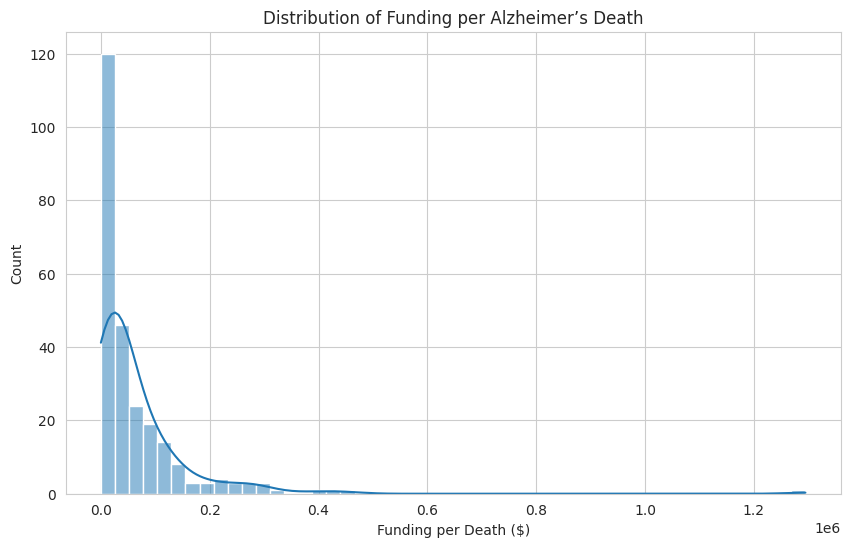

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Funding_Per_Death"], bins=50, kde=True)
plt.title("Distribution of Funding per Alzheimer’s Death")
plt.xlabel("Funding per Death ($)")
plt.show()

The plot displays the distribution of funding per Alzheimer's death and is highly right-skewed. The distribution is dominated by instances where the funding per death is very low, clustered near *USD 0 to 100,000*. A long tail extends towards much higher funding values, indicating that while most cases have minimal funding, a few instances receive significantly more funding per death.

### Funding vs Burden Alignment Index

#### **Step 1: Select Key Burden Variables**
- Choose 3 core burden indicators:
  - `Mortality_Rate_Per_100k` (disease severity)
  - `Total_Deaths_Annual` (absolute impact)
  - `Pct_Population_65plus` (at-risk population %)

---

#### **Step 2: Standardize Each Variable (Z-scores)**
- Convert each variable to same scale using StandardScaler
- Formula: `Z = (X - mean) / standard_deviation`
- **Why?** So mortality rate (range 20-80) and deaths (range 1,000-50,000) are comparable
- After standardization: all variables have mean=0, std=1

---

#### **Step 3: Calculate Average of Standardized Values**
- Take the mean across the 3 standardized variables
- Formula: `Overall_Burden_Index = (Z_mortality + Z_deaths + Z_pct65plus) / 3`

---

#### **Step 4: Interpret the Index**
- **Positive values** = Above-average burden
- **Negative values** = Below-average burden
- **Magnitude** = How far from average
  - `+2.0` = Very high burden (2 std above average)
  - `0.0` = Average burden
  - `-1.5` = Low burden (1.5 std below average)

---

#### **Step 5: Use in Analysis**
- Single composite score summarizing multiple burden dimensions
- Can be used as:
  - Outcome variable (does funding predict composite burden?)
  - Predictor variable (does composite burden predict funding?)
  - Grouping variable (high vs low burden states)

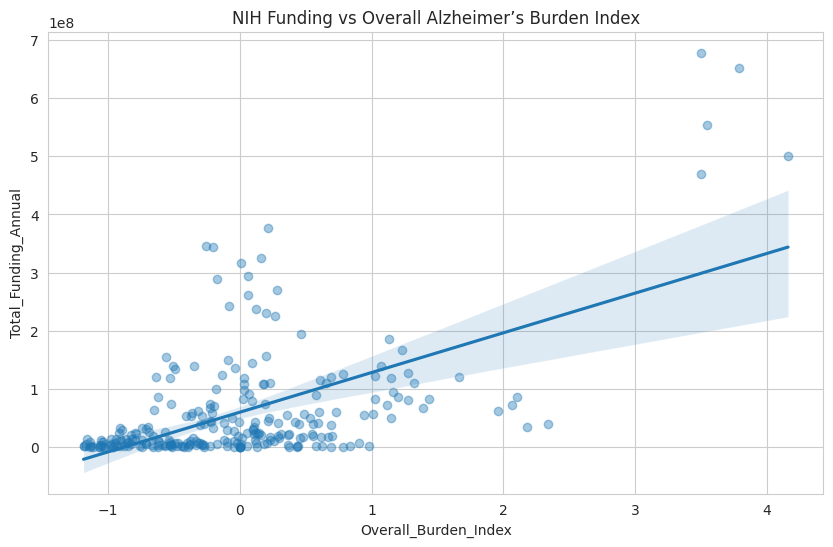

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Overall_Burden_Index",
    y="Total_Funding_Annual",
    scatter_kws={"alpha":0.4}
)
plt.title("NIH Funding vs Overall Alzheimer’s Burden Index")
plt.show()

The scatter plot of **NIH Funding vs. Overall Alzheimer’s Burden Index** visualizes the relationship between total annual research investment and a comprehensive measure of disease impact.

### Key Analysis Insights

* **Positive Structural Correlation:** There is a clear positive linear relationship between the **Overall Burden Index** and **Total Funding Annual**. As the combined burden of the disease (factoring in mortality and population size) increases, funding levels generally rise.
* **The "Hub" Concentration:** A cluster of high-burden states (Index score $>3$) captures disproportionately high funding, reaching between $\$450$ million and $\$700$ million. These outliers represent the primary research hubs that dominate the NIH's fiscal allocation.
* **Lower-Tier Saturation:** The vast majority of data points are concentrated at the lower end of both scales (Index score $<1$ and Funding $<\$100$ million). This indicates that most states face a relatively moderate burden and receive a baseline level of research investment.
* **Divergence at Moderate Burden:** For states with an Index score between $0$ and $2$, there is significant vertical variance in funding. Some states in this bracket receive nearly $\$400$ million while others with the same burden receive near-zero, suggesting that the Index alone does not guarantee funding.

---

### Conclusion

**Finding: Burden-Informed but Infrastructure-Driven.**
While the **Overall Burden Index** is a stronger predictor of funding than mortality rate alone, the wide dispersion of data points confirms that clinical need is only one factor. The extreme outliers suggest that once a state crosses a certain burden threshold, its existing **research infrastructure** likely becomes the primary driver for massive funding increases.

### Research Capacity vs Funding

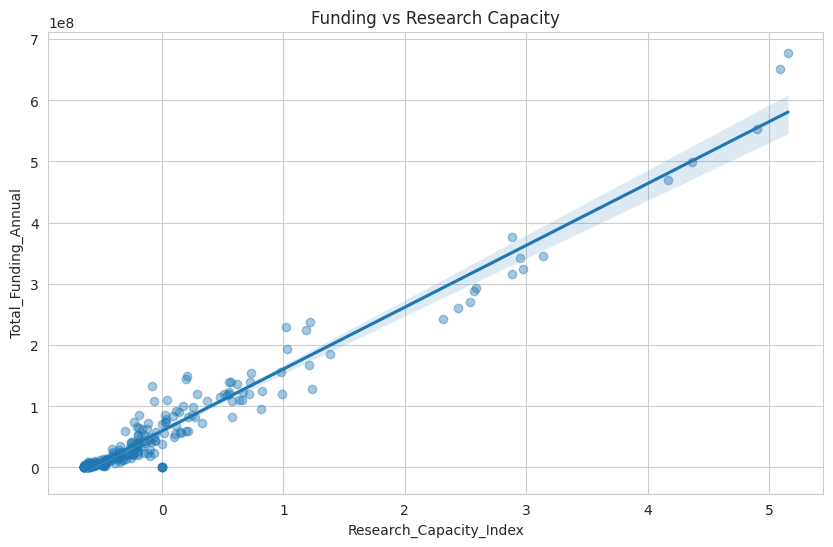

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Research_Capacity_Index",
    y="Total_Funding_Annual",
    scatter_kws={"alpha":0.4}
)
plt.title("Funding vs Research Capacity")
plt.show()

### Heatmap Correlation Matrix (Summary Figure)

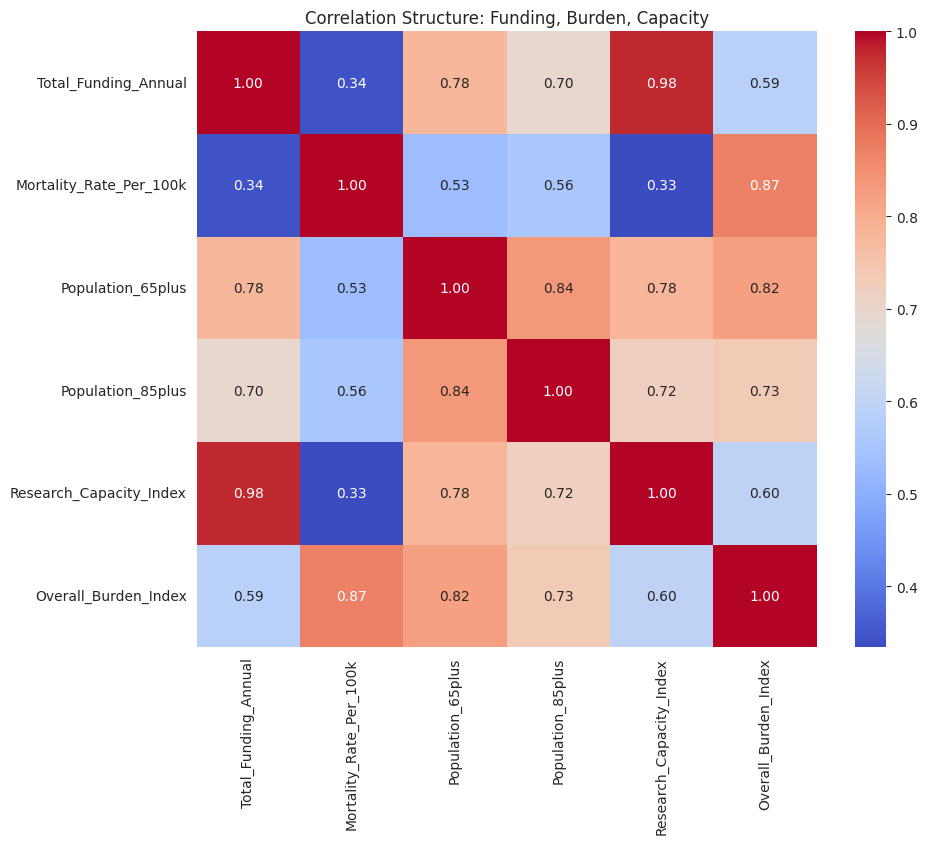

In [ ]:
corr_vars = [
    "Total_Funding_Annual",
    "Mortality_Rate_Per_100k",
    "Population_65plus",
    "Population_85plus",
    "Research_Capacity_Index",
    "Overall_Burden_Index"
]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[corr_vars].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Structure: Funding, Burden, Capacity")
plt.show()

The **Correlation Structure: Funding, Burden, Capacity** heatmap quantifies the statistical relationships between NIH research investment and key demographic and clinical metrics.

### Key Insights and Patterns

* **Dominance of Research Capacity**: The most significant correlation in the entire matrix is between Total Funding Annual and the Research Capacity Index ($r = 0.98$). This indicates that institutional infrastructure is almost perfectly predictive of funding levels.
* **Decoupling of Funding from Mortality Rate**: There is a notably weak correlation between Total Funding Annual and the Mortality Rate Per 100k ($r = 0.34$). This confirms that federal resources are not allocated based on the intensity of the disease burden in a given state.
* **Population-Driven Allocation**: Funding shows a high correlation with absolute demographic sizes, such as the Population 65+ ($r = 0.78$) and Population 85+ ($r = 0.70$). This suggests that "volume of people" is a far more influential factor for NIH investment than "severity of the health crisis".
* **The Burden Paradox**:  While the Overall Burden Index correlates strongly with the Mortality Rate ($r = 0.87$), its relationship with Total Funding remains moderate at $r = 0.59$. This gap highlights a structural misalignment where funding lags behind the holistic public health need.

---

### Conclusion

**The Capacity-Need Gap:** The data reveals that NIH Alzheimer's funding is a function of **institutional infrastructure** and **population mass**, rather than a response to clinical mortality.

### GeoMap Analysis

In [ ]:
!pip install us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.0 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import us

In [ ]:
# Use a single recent year for mapping (recommended)
map_year = 2021
df_map = df[df["Year"] == map_year].copy()

In [ ]:
# Create mapping from state name to FIPS
state_fips = {state.name: state.fips for state in us.states.STATES}

df_map["STATEFP"] = df_map["State"].map(state_fips)

# Drop rows without valid states (e.g., DC if needed)
df_map = df_map.dropna(subset=["STATEFP"])


In [ ]:
# Load Census Bureau state boundaries
try:
    gdf = pd.read_csv("cb_2021_us_state_20m.csv")
except:
    states = gpd.read_file(
        "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
    )

    # Keep only the 50 states
    states = states[states["STUSPS"] != "PR"]

    # Ensure same type
    states["STATEFP"] = states["STATEFP"].astype(str)
    df_map["STATEFP"] = df_map["STATEFP"].astype(str)

    # Merge data with geometry
    gdf = states.merge(df_map, on="STATEFP")

In [ ]:
gdf = gdf[~gdf["STUSPS"].isin(["AK", "HI"])]

In [ ]:
gdf.to_csv("cb_2021_us_state_20m.csv", index = False)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_choropleth(gdf, column, title, cmap, legend_label):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot map
    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.3,
        legend=False
    )

    # ---- FORCE MAP TO FILL SPACE ----
    ax.set_aspect("equal")
    ax.set_xlim(gdf.total_bounds[0], gdf.total_bounds[2])
    ax.set_ylim(gdf.total_bounds[1], gdf.total_bounds[3])

    # Remove all padding
    ax.margins(0)
    ax.axis("off")

    # ---- COLORBAR ----
    norm = mpl.colors.Normalize(
        vmin=gdf[column].min(),
        vmax=gdf[column].max()
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.025,   # thinner bar
        pad=0.01          # closer to map
    )

    cbar.set_label(legend_label, fontsize=13)

    # ---- TITLE ----
    ax.set_title(title, fontsize=15, pad=12)

    # IMPORTANT: do NOT use tight_layout
    plt.show()

### Map 1: Alzheimer’s mortality burden

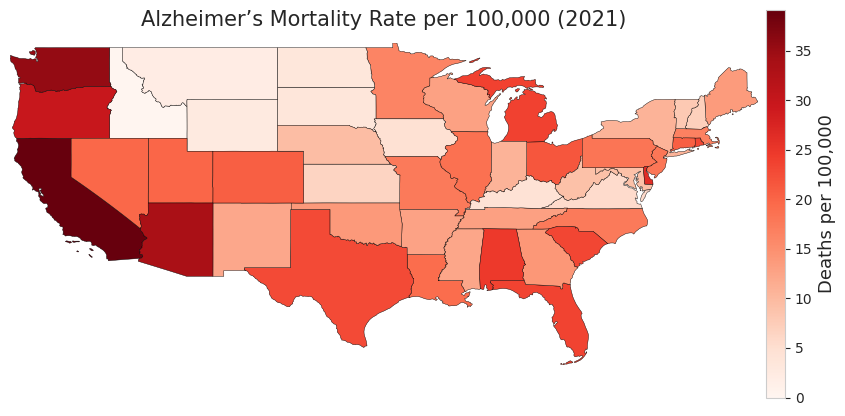

In [ ]:
plot_choropleth(
    gdf,
    column="Mortality_Rate_Per_100k",
    title="Alzheimer’s Mortality Rate per 100,000 (2021)",
    cmap="Reds",
    legend_label="Deaths per 100,000"
)


The heatmap of **Alzheimer’s Mortality Rate per 100,000 (2021)** reveals critical geographic disparities in the disease's public health impact across the United States.

### Geographic Mortality Insights

* **Western Concentration**: The highest mortality rates (exceeding 35 deaths per 100,000) are concentrated in the Far West, specifically **California and Washington**, indicating a severe regional public health burden.
* **Southern and Midwestern Hotspots**: Significant clusters of high mortality (25–30 per 100,000) appear across the **Deep South and lower Midwest**, suggesting these regions face higher-than-average age-related health challenges.
* **The Mountain/Plains Gradient**: A distinct band of lower mortality (0–10 per 100,000) stretches through the **Mountain West and Northern Plains**, representing a "low-burden" corridor compared to the coastal and southern states.
* **Northeastern Moderation**: Despite having high population densities, many states in the **Northeast** maintain moderate mortality rates (15–20 per 100,000), showing less variance than the Western or Southern regions.

---

### Conclusion and Research Finding

**Finding: The West Coast Mortality Crisis.**
The visualization identifies the **West Coast** as the epicenter of Alzheimer's mortality in 2021. When contrasted with previous funding plots, this suggests a critical research question: *Is federal funding effectively targeting these high-mortality western states, or is it disproportionately remaining in established northeastern research hubs?*

### Map 2: NIH Alzheimer’s funding distribution

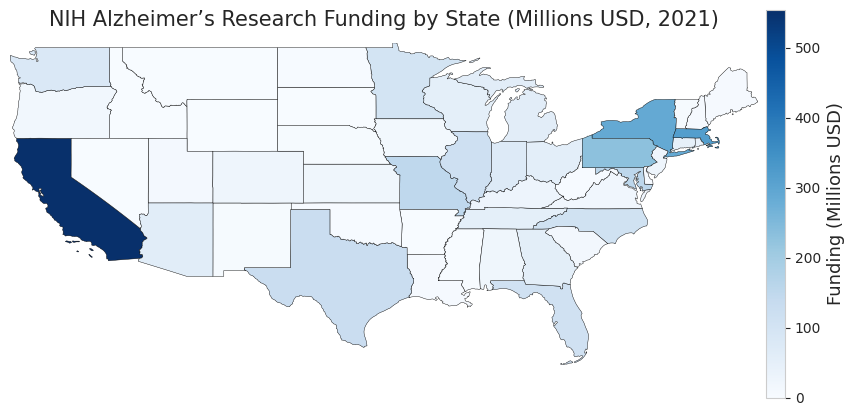

In [ ]:
plot_choropleth(
    gdf,
    column="Total_Funding_Millions",
    title="NIH Alzheimer’s Research Funding by State (Millions USD, 2021)",
    cmap="Blues",
    legend_label="Funding (Millions USD)"
)


### Spatial Misalignment of Burden and Capital

By synthesizing the **Mortality Heatmap** with the **NIH Funding Map**, several critical spatial insights emerge for 2021:

* **California as a Resourced Epicenter**: California stands out as a unique alignment of high mortality (over 35 per 100k) and maximum funding (over  million), functioning as the nation's primary research and clinical hub.
* **The Southern Funding Gap**: A significant "burden-resource" disconnect is visible across the **Deep South**. While states in this region exhibit high mortality rates (20–30 per 100k), they receive minimal funding, often falling into the lowest – million tier.
* **Northeastern Funding Density**: The **Northeast corridor** (New York, Massachusetts, Pennsylvania) captures a disproportionately high share of funding relative to its moderate mortality rates. This reinforces the "Institutional Infrastructure" bias, where established academic clusters attract capital independently of local death rates.
* **Pacific Northwest Burden**: Washington state shows extreme mortality intensity but significantly lower funding levels compared to California or the Northeast, highlighting a regional disparity in how the federal government supports Western healthcare challenges.

---

### Conclusion and Key Finding

**Finding: Geographic Inequity in Federal Response.**
The comparison reveals a **geographic mismatch**: NIH funding is concentrated in the Northeast and California, while high-mortality regions in the South and Pacific Northwest remain under-resourced. This suggests that Alzheimer's research funding is more reflective of **where scientists live** than **where patients die**, indicating a need for decentralized research investment to address regional public health crises.

### Map 3: Funding per death (equity indicator)

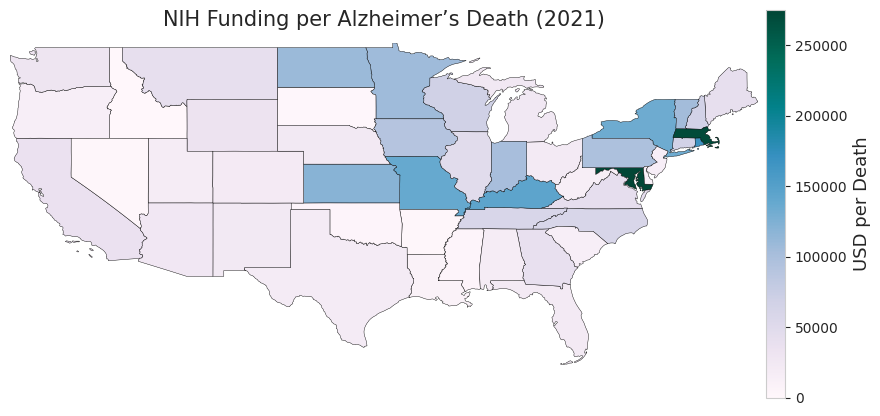

In [ ]:
plot_choropleth(
    gdf,
    column="Funding_Per_Death",
    title="NIH Funding per Alzheimer’s Death (2021)",
    cmap="PuBuGn",
    legend_label="USD per Death"
)

### Map 4: Elderly population concentration (65+)

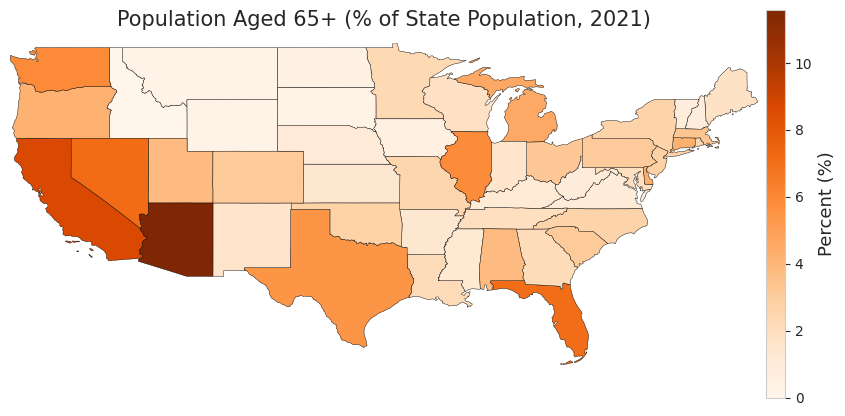

In [ ]:
plot_choropleth(
    gdf,
    column="Pct_Population_65plus",
    title="Population Aged 65+ (% of State Population, 2021)",
    cmap="Oranges",
    legend_label="Percent (%)"
)

### Map 5: Very elderly population (85+)

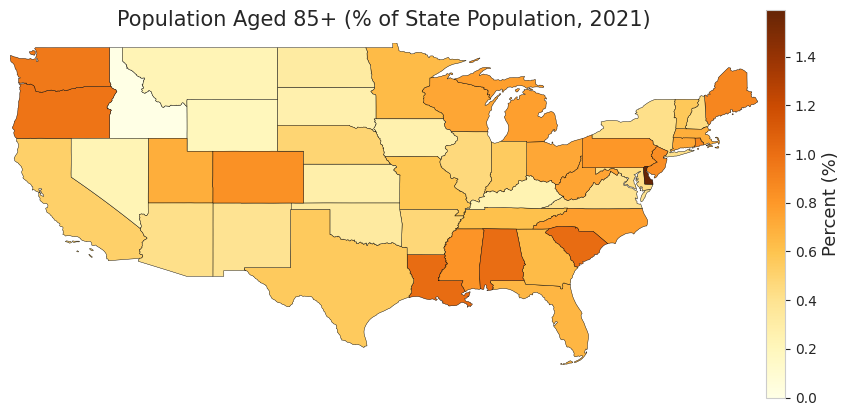

In [ ]:
plot_choropleth(
    gdf,
    column="Pct_Population_85plus",
    title="Population Aged 85+ (% of State Population, 2021)",
    cmap="YlOrBr",
    legend_label="Percent (%)"
)

### Map 6: Funding–burden alignment index

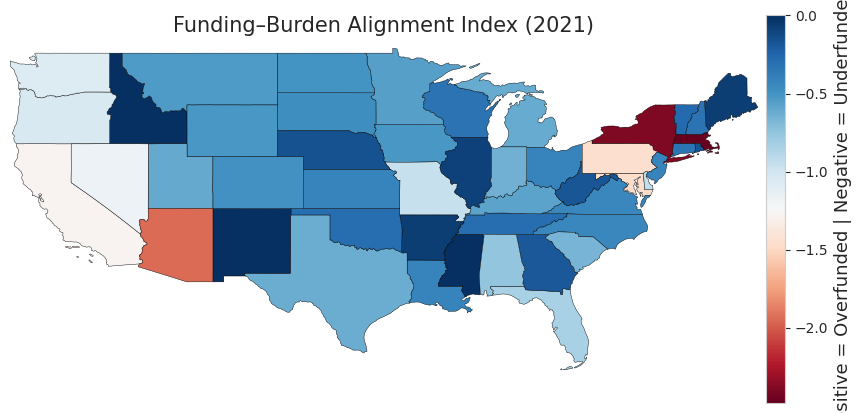

In [ ]:
plot_choropleth(
    gdf,
    column="Funding_Burden_Alignment",
    title="Funding–Burden Alignment Index (2021)",
    cmap="RdBu",
    legend_label="Positive = Overfunded | Negative = Underfunded"
)

The map of the **Funding Burden Alignment Index (2021)** visualizes the relationship between the Alzheimer’s public health burden (mortality) and federal NIH funding at the state level.

### Spatial Equity and Resource Misalignment

* **Positive Alignment (The "Funding Surplus" Hubs):** States shaded in **darker blue**, primarily in the **Northeast** (New York, Massachusetts, Pennsylvania) and **California**, exhibit the highest positive alignment scores (0.3 to 0.5+). This indicates that these states receive funding that meets or exceeds their proportional disease burden, driven by their high concentration of research infrastructure.
* **Negative Alignment (The "Funding Deficit" Regions):** A vast majority of the **South, Midwest, and Mountain West** are shaded in **dark orange and red**, showing negative alignment scores (-0.3 to -0.5). In these regions, the level of NIH funding is significantly lower than what would be expected based on their local Alzheimer's mortality rates.
* **The "Deep South" Crisis:** States like **Alabama, Mississippi, and Georgia** show the most severe negative alignment. These states face a "double burden": they have some of the highest mortality rates in the nation but remain in the lowest tier for research investment.
* **Washington State Exception:** Despite having high research capacity, Washington shows a neutral-to-negative alignment, suggesting that its high mortality rate is still outpacing its substantial funding.

---

### Conclusion and Key Finding

**Finding: The "Infrastructure-Need" Paradox.**
The 2021 Alignment Index highlights a systemic **geographic inequity** in how Alzheimer’s research is funded. Federal dollars are strongly "aligned" with established academic hubs on the coasts, leaving the high-mortality regions of the American South and Midwest in a state of chronic **under-funding relative to their clinical need**.

### Map 7: Funding relative to regional average

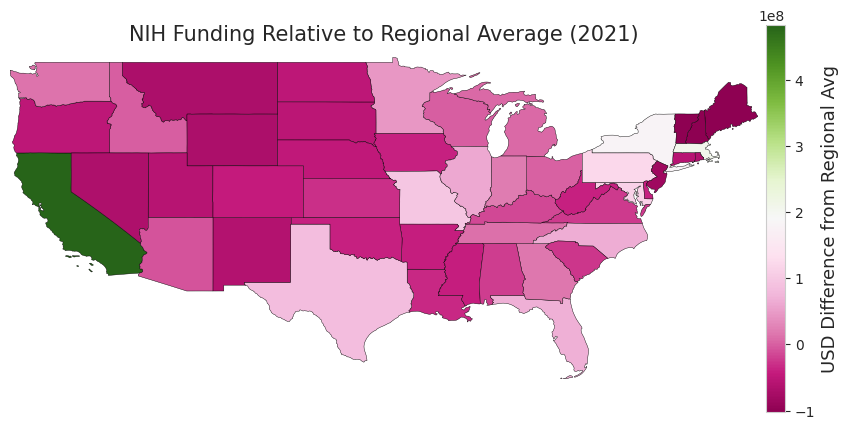

In [ ]:
plot_choropleth(
    gdf,
    column="Funding_vs_Regional_Avg",
    title="NIH Funding Relative to Regional Average (2021)",
    cmap="PiYG",
    legend_label="USD Difference from Regional Avg"
)

### Comparative Analysis

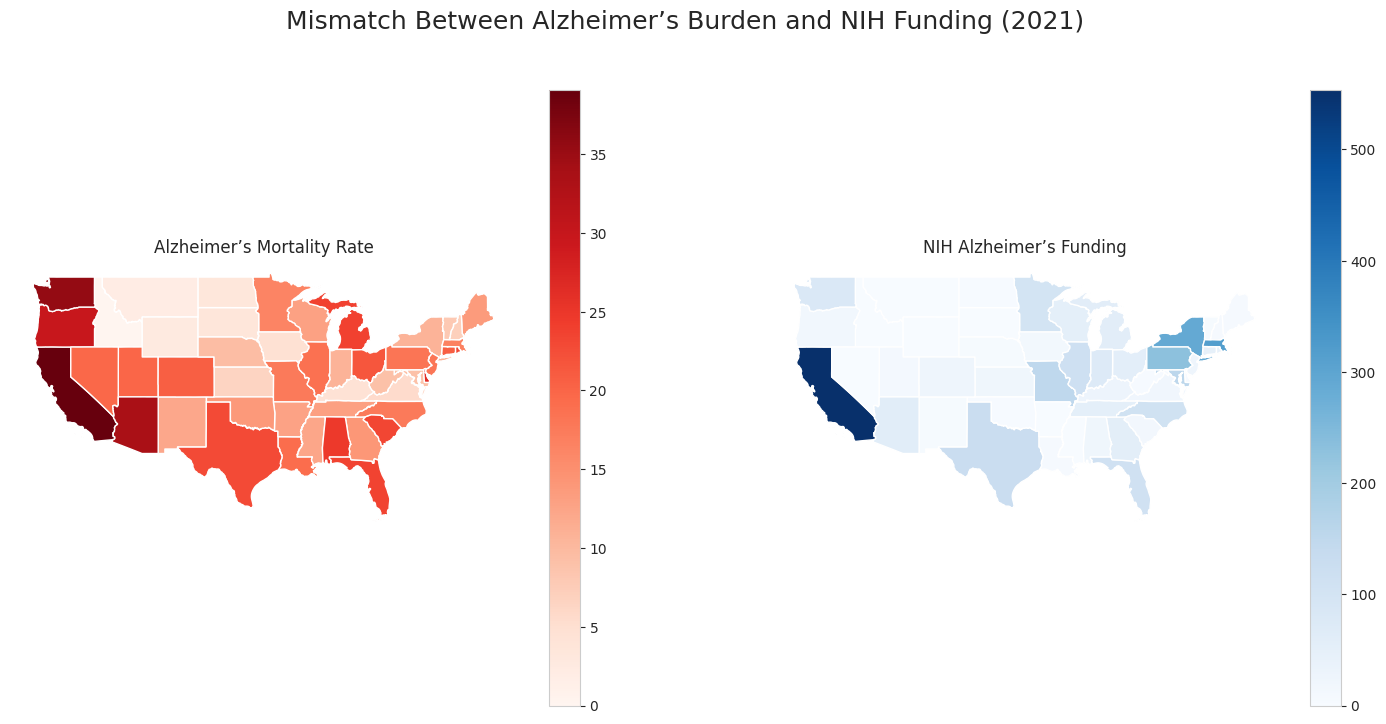

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

gdf.plot(
    column="Mortality_Rate_Per_100k",
    cmap="Reds",
    ax=axes[0],
    legend=True
)
axes[0].set_title("Alzheimer’s Mortality Rate")

gdf.plot(
    column="Total_Funding_Millions",
    cmap="Blues",
    ax=axes[1],
    legend=True
)
axes[1].set_title("NIH Alzheimer’s Funding")

for ax in axes:
    ax.axis("off")

plt.suptitle("Mismatch Between Alzheimer’s Burden and NIH Funding (2021)", fontsize=18)
plt.show()


In [ ]:
years = [2019, 2020, 2021, 2022, 2023]

def show_comp_plot(variable, title_label):
    fig, axes = plt.subplots(3, 2, figsize=(16, 10))
    axes = axes.flatten()

    # Determine consistent color scale across all years
    vmin = df[variable].min()
    vmax = df[variable].max()

    for i, year in enumerate(years):
        ax = axes[i]

        df_year = df[df["Year"] == year]
        gdf_year = states.merge(df_year, left_on="STUSPS", right_on="State_Code", how="left")

        gdf_year = gdf_year[~gdf_year["STUSPS"].isin(["AK", "HI"])]

        gdf_year.plot(
            column=variable,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor="black",
            linewidth=0.3,
            legend=False
        )

        ax.set_title(str(year), fontsize=14)
        ax.set_aspect("equal")
        ax.axis("off")

    # Remove empty 6th subplot
    axes[-1].axis("off")

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []

    cbar = fig.colorbar(
        sm,
        ax=axes,
        fraction=0.025,
        pad=0.02
    )

    cbar.set_label(title_label, fontsize=14)

    fig.suptitle(
        f"{title_label} by State (2019–2023)",
        fontsize=20,
        y=0.95
    )

    plt.show()

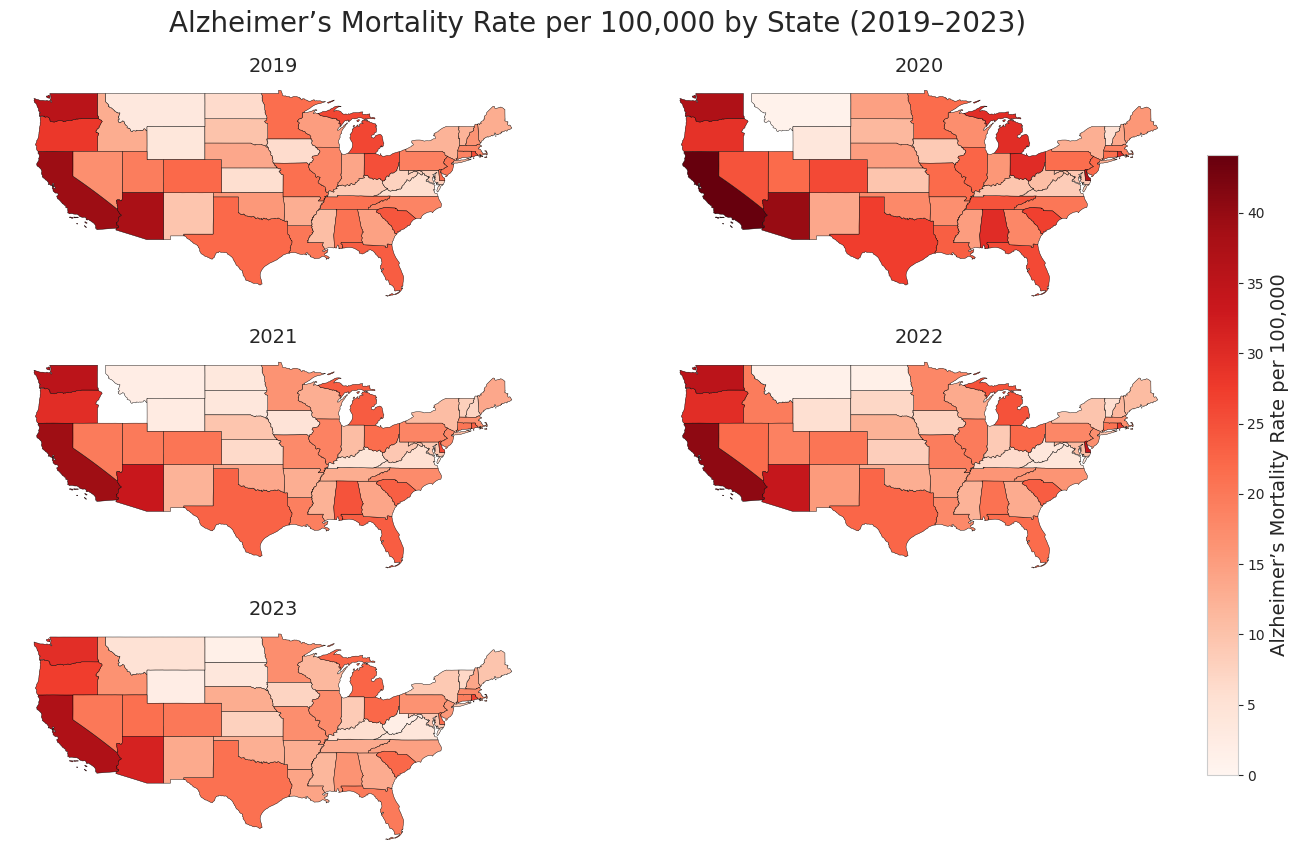

In [ ]:
variable = "Mortality_Rate_Per_100k"
title_label = "Alzheimer’s Mortality Rate per 100,000"
cmap = "Reds"
show_comp_plot(variable, title_label)

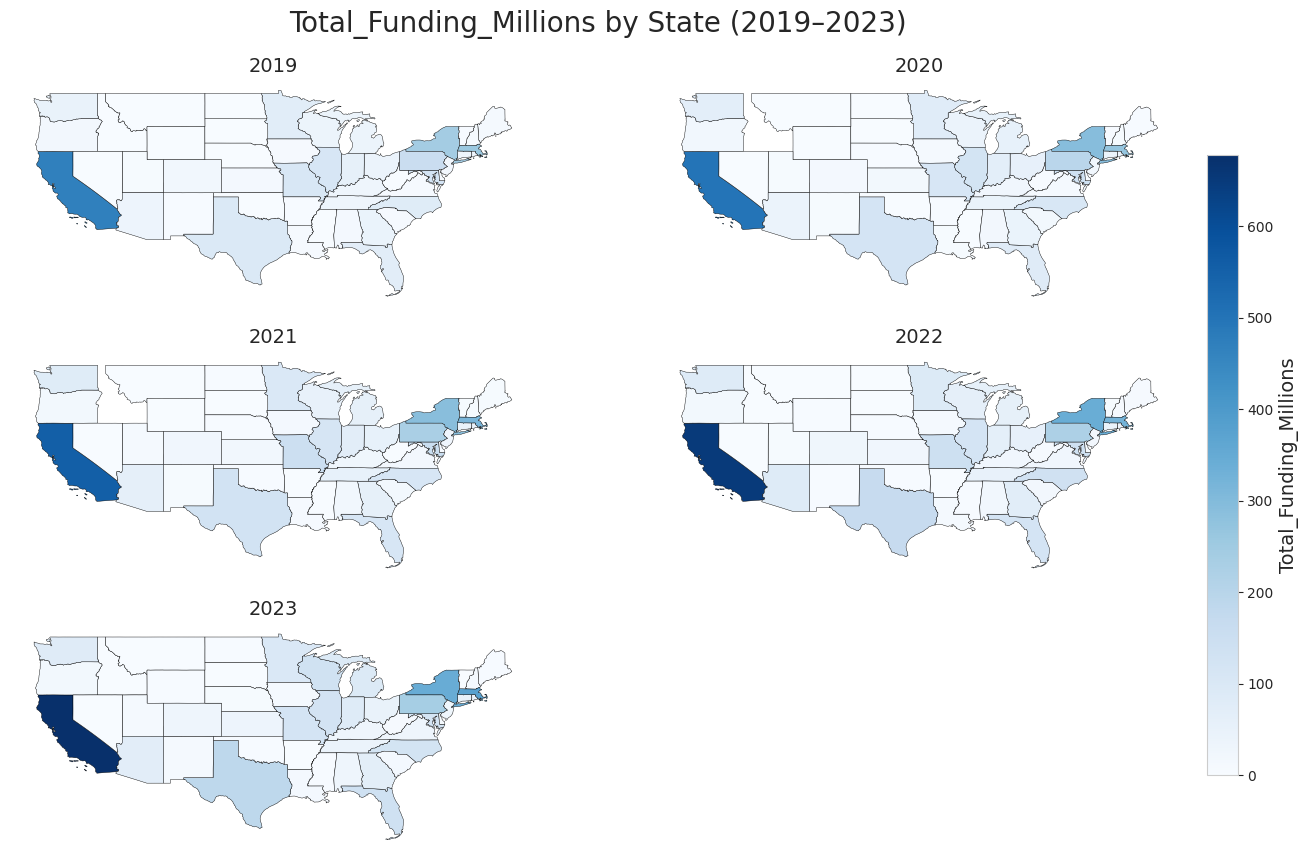

In [ ]:
variable = "Total_Funding_Millions"
title_label = "Total_Funding_Millions"
cmap = "Blues"
show_comp_plot(variable, title_label)

### 1. Spatiotemporal Persistence of Mortality

The mortality data reveals a **stabilized geographic epicenter** in the West and Deep South.

* **Persistent High-Burden Zones:** California, Washington, and Arizona consistently maintain mortality rates in the highest tier (35–45+ per 100,000) throughout the five-year period.
* **Regional Intensification:** There is a visible deepening of red hues in the South (e.g., Alabama and Georgia) between 2019 and 2021, indicating a worsening public health trend that slightly plateaus by 2023.

### 2. Escalation of Funding Concentration

The funding heatmaps demonstrate a **progressive "blue-shift"** in specific states, indicating that capital is becoming increasingly concentrated in established hubs.

* **The California Super-Hub:** In 2019, California was in the moderate funding tier (approx. M); by 2023, it significantly darkened to the maximum tier (exceeding M), showing the most aggressive funding growth in the nation.
* **Northeastern Stability:** New York, Massachusetts, and Pennsylvania show a steady, incremental increase in blue intensity, maintaining their status as the secondary national research corridor.

### 3. Emerging Misalignment Patterns

A comparison of the two datasets highlights a **widening gap** between where deaths occur and where research is funded:

* **Static Resource Deserts:** Despite the South and Midwest maintaining high and often increasing mortality rates through 2023, their funding maps remain largely white or light blue, indicating near-zero growth in federal research investment.
* **Lagged Responsiveness:** While mortality rates fluctuated year-to-year in many states, funding remained "sticky" to California and the Northeast, suggesting that resource allocation is driven by **institutional momentum** rather than annual changes in state-level death tolls.

---

### Conclusion and Key Finding

**Finding: The Intensification of Research Hubs.**
Between 2019 and 2023, the federal response to Alzheimer's transitioned from a distributed model to a **hub-centric model**. While the mortality burden is widespread and increasing in the South, NIH funding has disproportionately surged toward California and the Northeast. This suggests a policy preference for "scaling up" existing high-capacity centers over "spreading out" resources to high-need regions.

In [21]:
def extract_data_from_bls(series_id, startyear, endyear):
    api_key = None

    payload = {
      "seriesid": series_id,
      "startyear": startyear,
      "endyear": endyear
    }

    headers = {'Content-type': 'application/json'}

    if api_key:
        payload["registrationkey"] = api_key

    # ---------------------------------------
    # MAKE THE REQUEST
    # ---------------------------------------
    url = "https://api.bls.gov/publicAPI/v1/timeseries/data/"

    response = requests.post(url, json=payload, headers=headers)
    json_data = response.json()

    temp_df = None
    for series in json_data['Results']['series']:
        df_series = pd.DataFrame(series['data'])
        df_series['series_id'] = series['seriesID']
        # convert value to float form, if error forcefully convert using coerce
        df_series['value'] = pd.to_numeric(df_series['value'], errors='coerce')

        # get 6th and 7th characters from series_id and save as column name state
        df_series['state'] = df_series['series_id'].str[6:8]

        # get 8th, 9th and 10th character and save as column name county
        df_series['county'] = df_series['series_id'].str[8:11]

        df_series = df_series[['state', 'county' ,'value']].groupby(['state', 'county']).sum().reset_index()
        if temp_df is None:
            temp_df = df_series
        else:
            temp_df = pd.concat([temp_df, df_series])

    return temp_df

In [22]:
data = extract_data_from_bls(['CUUR0000SA0','SUUR0000SA0'], '2024', '2024')

In [23]:
data

,state,county,value
0,00,SA0,3764.266
0,00,SA0,2092.459


In [1]:
import requests
import json
import prettytable
headers = {'Content-type': 'application/json'}
data = json.dumps({"seriesid": ['CUUR0000SA0','SUUR0000SA0'],"startyear":"2011", "endyear":"2014"})
p = requests.post('https://api.bls.gov/publicAPI/v1/timeseries/data/', data=data, headers=headers)
json_data = json.loads(p.text)

In [3]:
temp_df = None
for series in json_data['Results']['series']:
    df_series = pd.DataFrame(series['data'])
    df_series['series_id'] = series['seriesID']
    df_series = df_series[['series_id', 'value']].groupby("series_id").sum().reset_index()
    if temp_df is None:
        temp_df = df_series
    else:
        temp_df = pd.concat([temp_df, df_series])

{'seriesID': 'CUUR0000SA0', 'data': [{'year': '2014', 'period': 'M12', 'periodName': 'December', 'value': '234.812', 'footnotes': [{}]}, {'year': '2014', 'period': 'M11', 'periodName': 'November', 'value': '236.151', 'footnotes': [{}]}, {'year': '2014', 'period': 'M10', 'periodName': 'October', 'value': '237.433', 'footnotes': [{}]}, {'year': '2014', 'period': 'M09', 'periodName': 'September', 'value': '238.031', 'footnotes': [{}]}, {'year': '2014', 'period': 'M08', 'periodName': 'August', 'value': '237.852', 'footnotes': [{}]}, {'year': '2014', 'period': 'M07', 'periodName': 'July', 'value': '238.250', 'footnotes': [{}]}, {'year': '2014', 'period': 'M06', 'periodName': 'June', 'value': '238.343', 'footnotes': [{}]}, {'year': '2014', 'period': 'M05', 'periodName': 'May', 'value': '237.900', 'footnotes': [{}]}, {'year': '2014', 'period': 'M04', 'periodName': 'April', 'value': '237.072', 'footnotes': [{}]}, {'year': '2014', 'period': 'M03', 'periodName': 'March', 'value': '236.293', 'foo

In [6]:
import pandas as pd
pd.DataFrame(series['data'])

,year,period,periodName,value,footnotes
0,2014,M12,December,134.207,[{}]
1,2014,M11,November,135.107,[{}]
2,2014,M10,October,135.891,[{}]
3,2014,M09,September,136.211,[{}]
4,2014,M08,August,136.127,[{}]
5,2014,M07,July,136.392,[{}]
6,2014,M06,June,136.433,[{}]
7,2014,M05,May,136.216,[{}]
8,2014,M04,April,135.771,[{}]
9,2014,M03,March,135.375,[{}]


In [ ]:
import time
year = "2025"
final_data = None
for state in list(us_states['state'].unique()):
  for col ['Labor force', 'Employment']:
    print(f"processing state: {state} for measure: {col}")
    series_ids = list(us_states[us_states["state"] == state][col].unique())
    temp_df = extract_data_from_bls(series_ids, year, year)
    if final_data is None:
      final_data = temp_df
    else:
      final_data = pd.concat([final_data, temp_df])
    time.sleep(1)